In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import io, base64, os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import folium
from folium.plugins import HeatMap

In [26]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Disaster-Risk-Predictor-main (2)\Disaster-Risk-Predictor-main\data\raw\raw_data.csv")

print(df.head())
print(df.shape)

    Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
0  18.861663  78.835584     218.999493         34.144337     43.912963   
1  35.570715  77.654451      55.353599         28.778774     27.585422   
2  29.227824  73.108463     103.991908         43.934956     30.108738   
3  25.361096  85.610733     198.984191         21.569354     34.453690   
4  12.524541  81.822101     144.626803         32.635692     36.292267   

   River Discharge (m³/s)  Water Level (m)  Elevation (m)    Land Cover  \
0             4236.182888         7.415552     377.465433    Water Body   
1             2472.585219         8.811019    7330.608875        Forest   
2              977.328053         4.631799    2205.873488  Agricultural   
3             3683.208933         2.891787    2512.277800        Desert   
4             2093.390678         3.188466    2001.818223  Agricultural   

  Soil Type  Population Density  Infrastructure  Historical Floods  \
0      Clay         7276.742184   

In [27]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Rainfall (mm)": "rainfall",
    "Temperature (°C)": "temperature",
    "Humidity (%)": "humidity",
    "River Discharge (m³/s)": "river_discharge",
    "Water Level (m)": "water_level",
    "Elevation (m)": "elevation",
    "Land Cover": "land_cover",
    "Soil Type": "soil_type",
    "Population Density": "population_density",
    "Infrastructure": "infrastructure",
    "Historical Floods": "past_disasters",
    "Flood Occurred": "flood_occurred"
})

df = df.drop_duplicates()

numeric_cols = [
    "rainfall","temperature","humidity",
    "river_discharge","water_level","elevation",
    "population_density","past_disasters",
    "latitude","longitude","flood_occurred"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

df["land_cover"] = df["land_cover"].astype("category")
df["soil_type"] = df["soil_type"].astype("category")

df["past_disasters"] = df["past_disasters"].astype(int)
df["flood_occurred"] = df["flood_occurred"].astype(int)

df.head()

,latitude,longitude,rainfall,temperature,humidity,river_discharge,water_level,elevation,land_cover,soil_type,population_density,infrastructure,past_disasters,flood_occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [28]:
df["risk_index"] = df["rainfall"] * df["population_density"]

low_th = df["risk_index"].quantile(0.33)
high_th = df["risk_index"].quantile(0.66)

def label_risk(value):
    if value < low_th:
        return 0
    elif value < high_th:
        return 1
    else:
        return 2

df["risk_label"] = df["risk_index"].apply(label_risk)

df.head()

,latitude,longitude,rainfall,temperature,humidity,river_discharge,water_level,elevation,land_cover,soil_type,population_density,infrastructure,past_disasters,flood_occurred,risk_index,risk_label
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1,1.593603e+06,2
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0,3.818146e+05,1
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1,4.535626e+05,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0,1.226353e+06,2
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0,8.920530e+05,1


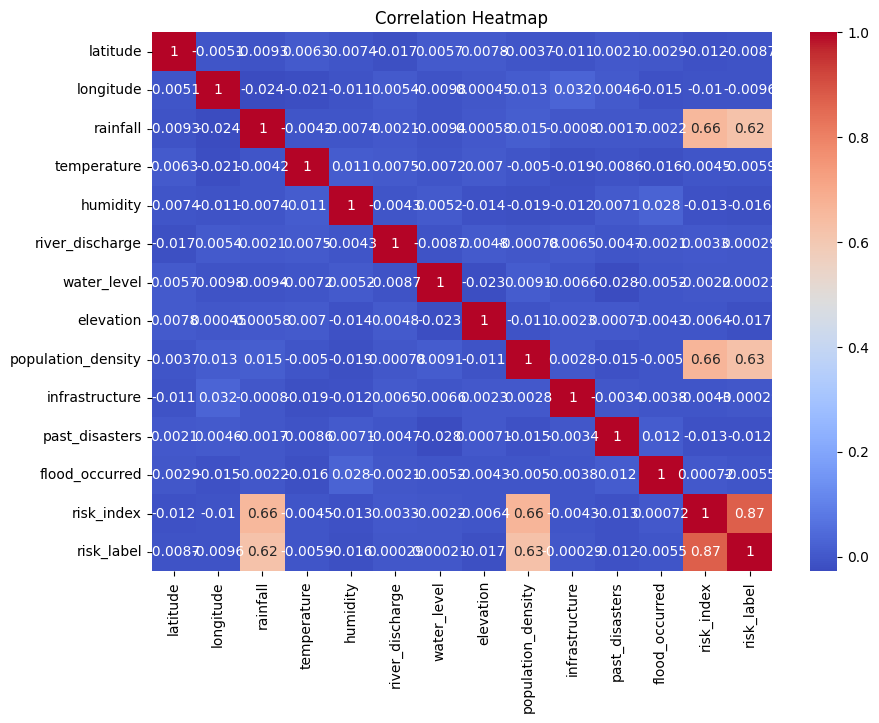

In [29]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

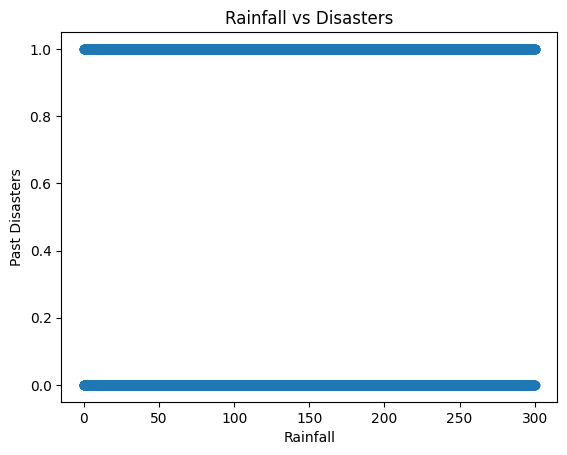

In [30]:
plt.figure()

plt.scatter(
    df["rainfall"],
    df["past_disasters"]
)

plt.xlabel("Rainfall")
plt.ylabel("Past Disasters")

plt.title("Rainfall vs Disasters")

plt.show()

In [31]:
le = LabelEncoder()

df["land_cover"] = le.fit_transform(df["land_cover"].astype(str))
df["soil_type"] = le.fit_transform(df["soil_type"].astype(str))

In [32]:
FEATURE_COLS = [
    "rainfall",
    "temperature",
    "humidity",
    "river_discharge",
    "water_level",
    "elevation",
    "land_cover",
    "soil_type",
    "population_density",
    "infrastructure",
    "past_disasters",
    "risk_index"
]

TARGET_COL = "risk_label"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(len(X_train), len(X_test))

8000 2000


In [34]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)

print("Logistic Regression Accuracy:", lr_acc)

print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.936
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       658
           1       0.91      0.90      0.90       665
           2       0.95      0.97      0.96       677

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_acc)

print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       658
           1       1.00      1.00      1.00       665
           2       1.00      1.00      1.00       677

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



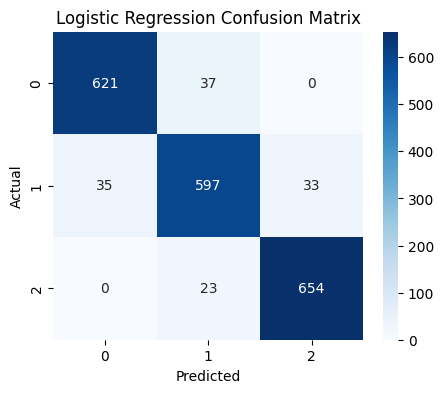

In [36]:
cm_lr = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

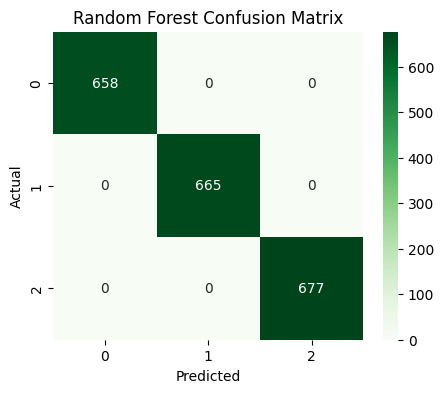

In [37]:
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
if rf_acc >= lr_acc:
    best_model = rf_model
    print("Best Model: Random Forest")

else:
    best_model = lr_model
    print("Best Model: Logistic Regression")

Best Model: Random Forest


In [39]:
df["predicted_risk"] = best_model.predict(X)

df.head()

,latitude,longitude,rainfall,temperature,humidity,river_discharge,water_level,elevation,land_cover,soil_type,population_density,infrastructure,past_disasters,flood_occurred,risk_index,risk_label,predicted_risk
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,4,0,7276.742184,1,0,1,1.593603e+06,2,2
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,2,2,6897.736956,0,1,0,3.818146e+05,1,1
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,0,1,4361.518494,1,1,1,4.535626e+05,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,1,3,6163.069701,1,1,0,1.226353e+06,2,2
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,0,1,6167.964591,1,0,0,8.920530e+05,1,1


In [40]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=90)
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return encoded

In [41]:
INDIA_STATES = [

    ("Jammu & Kashmir",32.5,37.0,73.0,80.0),
    ("Himachal Pradesh",30.4,33.2,75.6,79.0),
    ("Punjab",29.5,32.5,73.9,76.9),
    ("Uttarakhand",28.7,31.5,77.6,81.1),
    ("Haryana",27.7,30.9,74.4,77.6),
    ("Delhi",28.4,28.9,76.8,77.4),
    ("Rajasthan",23.0,30.2,69.5,78.3),
    ("Uttar Pradesh",23.9,30.4,77.1,84.6),
    ("Bihar",24.3,27.5,83.3,88.3),
    ("Sikkim",27.0,28.1,88.0,88.9),
    ("West Bengal",21.5,27.2,85.8,89.9),
    ("Assam",24.1,27.9,89.7,96.0),
    ("Meghalaya",25.0,26.1,89.8,92.8),
    ("Arunachal Pradesh",26.6,29.5,91.5,97.4),
    ("Nagaland",25.2,27.0,93.3,95.2),
    ("Manipur",23.8,25.7,93.0,94.8),
    ("Mizoram",21.9,24.5,92.3,93.4),
    ("Tripura",22.9,24.5,91.2,92.3),
    ("Jharkhand",21.9,25.3,83.3,87.9),
    ("Odisha",17.8,22.6,81.4,87.5),
    ("Chhattisgarh",17.8,24.1,80.2,84.4),
    ("Madhya Pradesh",21.1,26.9,74.0,82.8),
    ("Gujarat",20.1,24.7,68.2,74.5),
    ("Maharashtra",15.6,22.0,72.6,80.9),
    ("Telangana",15.8,19.9,77.2,81.3),
    ("Andhra Pradesh",12.6,19.9,76.8,84.7),
    ("Karnataka",11.6,18.4,74.1,78.6),
    ("Goa",14.9,15.8,73.9,74.4),
    ("Kerala",8.1,12.8,74.9,77.4),
    ("Tamil Nadu",8.1,13.6,76.2,80.4)

]


In [42]:
def get_region_name(lat, lon):

    for name, lat_min, lat_max, lon_min, lon_max in INDIA_STATES:

        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:

            return name

    return None



In [44]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Disaster-Risk-Predictor-main (2)\Disaster-Risk-Predictor-main\data\processed\final_data.csv")

print("Loaded rows:", len(df))



Loaded rows: 10000


In [45]:

if "predicted_risk" not in df.columns:

    raise ValueError("Run model.py first")



df["region"] = df.apply(

    lambda r: get_region_name(

        r["latitude"],
        r["longitude"]

    ),

    axis=1
)


In [46]:
df = df[df["region"].notna()].copy()



COLOR_MAP = {

    0:"green",

    1:"orange",

    2:"red"
}



LABEL_MAP = {

    0:"Low",

    1:"Medium",

    2:"High"
}



BG_COLOR = {

    0:"#e8f5e9",

    1:"#fff8e1",

    2:"#ffebee"
}

In [47]:
risk_counts = df["predicted_risk"].value_counts().sort_index()



fig_g, ax_g = plt.subplots(

    figsize=(3,2)

)



bars = ax_g.bar(

    [LABEL_MAP[i] for i in risk_counts.index],

    risk_counts.values,

    color=[COLOR_MAP[i] for i in risk_counts.index]

)



global_chart_b64 = fig_to_base64(fig_g)



risk_map = folium.Map(

    location=[

        df["latitude"].mean(),

        df["longitude"].mean()

    ],

    zoom_start=5

)



In [48]:
heat_data = df[

    ["latitude","longitude","predicted_risk"]

].values.tolist()



HeatMap(

    heat_data,

    radius=15,

    blur=20

).add_to(risk_map)



for _, row in df.sample(

    n=min(300,len(df)),

    random_state=42

).iterrows():


    risk_val = int(row["predicted_risk"])


    folium.CircleMarker(

        location=[

            row["latitude"],

            row["longitude"]

        ],

        radius=7,

        color=COLOR_MAP[risk_val],

        fill=True

    ).add_to(risk_map)



os.makedirs(

    "outputs/maps",

    exist_ok=True
)



risk_map.save(

    "outputs/maps/risk_map.html"
)



risk_map